# PODCNF Library

This notebook will explain you how to use properly the library from the loading of the data, following the POD, the data preprocessing, the training and finally to evaluate the goodness of the model.

> Imports and device setting

In [1]:
import torch

SEED = 42

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
else:
    device = torch.device("cpu")
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))

/tmp/ipykernel_26877/2767298464.py:8: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))


In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.12.0+cpu
Device: cpu


## Loading Data

In this section you should upload you data. These are composed by the soultions $u$, that might be your reference data to infer on, and the conditioning parameters in the vector $\mu$.
These two ingredients must be tensors on the same device.

In [4]:
data = torch.load("../data/data_linear_density_2pi.pt", weights_only=True)
u = data['u_data'].to(device)
mass = data['mass']
delta = data['delta']
mu = torch.cat([mass, delta], dim = 1).to(device)
dim_mu = mu.shape[1]

## POD

Once data are loaded the POD must be computed to project the data into a low dimensional space obtaining the latent coefficients that are then used to train the model.

Note that here ```n_train``` and ```n_val``` are meant to be index that separates the training set from the validation set, so then the rest of the data could be used to test the model.

In [5]:
n_samples = u.shape[0]
n_train = int(n_samples * 0.75)
n_val = int(n_train + n_samples * 0.2)

/home/andreaviolante1501/podcnf/.venv/lib/python3.12/site-packages/dlroms/fespaces.py:51: UserWarning: Either dolfin or fenics are not available. Some functions might not be available or work as expected.
  warnings.warn("Either dolfin or fenics are not available. Some functions might not be available or work as expected.")


<Figure size 700x500 with 0 Axes>

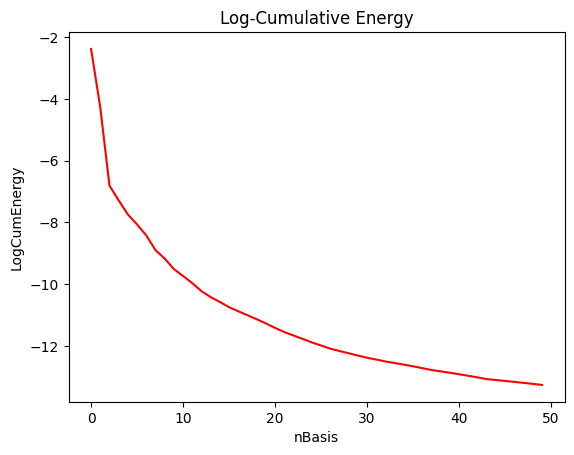

In [6]:
from podcnf import PODcnf

V, svalues = PODcnf.svd(u[:n_train, :].T)
PODcnf.svdplot(svalues, nmax = 50, logscale = True)

In [7]:
from dlroms import euclidean
from dlroms import num2p

n = PODcnf.nmin(svalues, threshold = 0.99999)
Vpod = V[:, :n]
print(f"Choosen number of basis: {n}")
errors = PODcnf.projection_errors(u[n_train:n_val, :], Vpod, relative = True, norm = euclidean)
print("Basis projection error: %s." % num2p(errors.mean()))

Choosen number of basis: 20
Basis projection error: 0.36%.


## Data Preprocessing

In this section we project the data into the low-dimensional space applying the POD matrix ```Vpod```. The obtained latent coephicients should be then normalized before the training.

In [8]:
c = u @ Vpod
dim_c = c.shape[1]

/tmp/ipykernel_26877/2791962395.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  c = u @ Vpod


In [9]:
n_samples = 1000
n_train = int(n_samples * 0.75)
n_val = int(n_train + n_samples * 0.2)

In [10]:
from podcnf.DataManage import DataPreprocessing

train_data, val_data, test_data, mu_scaler, c_scaler = DataPreprocessing(
    mu[:1000], c[:1000], n_train, n_val, BATCH_SIZE = 64
)

## Tuning and Training

In [11]:
from podcnf.NFmodel import NormalizingFlow

For the Tuning and Training section, one could may skip the tuning phase and just set a desired set of hyperparameters.

In [12]:
# Enable mixed precision training for GPU acceleration
if torch.cuda.is_available():
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
else:
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))

/tmp/ipykernel_26877/917629575.py:5: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))


One should first tune the hyperparameters and subsequently set them as input for the training phase.

In [13]:
lr = [1e-3]
num_flows = [12, 16]
hidden_size = [64, 128]
hidden_depth = [1]
wd = [1e-5]

tuning_epochs = 50
print_frequency = 10
patience = 20

In [14]:
best_hyperparams = NormalizingFlow.tune_flow(
    train_data, val_data,
    lr, num_flows, hidden_size, hidden_depth, wd,
    tuning_epochs, print_frequency, patience,
    dim_mu, dim_c
)


 Start Tuning:

--- Execution 1/4: run_1_flows_12_hidden_64_depth_1_lr_0.001_wd_1e-05 ---
Training 50 epochs:


/home/andreaviolante1501/podcnf/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/50 | Train: Loss=28.6971 | Val: Loss=26.1471
Epoch  10/50 | Train: Loss=8.2880 | Val: Loss=9.0403
    -> New best self saved with Val Loss: 9.0403


KeyboardInterrupt: 

In [ ]:
num_flows = best_hyperparams['num_flows']
hidden_size=best_hyperparams['hidden_size'] 
hidden_depth=best_hyperparams['hidden_depth']

In [ ]:
from podcnf.NFmodel import NormalizingFlow

flow = NormalizingFlow(
    dim_mu, dim_c, 
    num_flows=best_hyperparams['num_flows'], 
    hidden_size=best_hyperparams['hidden_size'], 
    hidden_depth=best_hyperparams['hidden_depth'], 
    device=device
).to(device)

In [ ]:
model_save_path = '../results/TrialModel.pt'

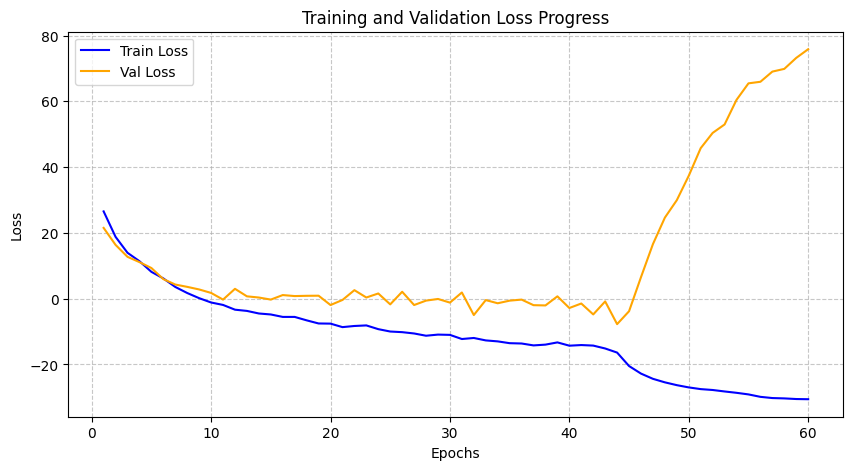

Epoch  60/80 | Train: Loss=-30.5669 | Val: Loss=75.8418

--- Early Stopping ---
Validation is not improving since 20 epochs.
Interrupted training 64.

Training completed. Best self saved to: '../results/TrialModel.pt'
Best Validation Loss achieved: -7.7397


In [ ]:
train_losses, val_losses = flow.train_flow(
    epochs=80, 
    print_frequency=10, 
    train_data = train_data, 
    val_data = val_data, 
    lr = best_hyperparams['learning_rate'], 
    weight_decay = best_hyperparams['weight_decay'], 
    patience = 20, 
    model_save_path = model_save_path, 
    show_plot=True
)

## Save the model

In [ ]:
flow_parameters = {
    'num_flows': best_hyperparams['num_flows'],
    'hidden_size': best_hyperparams['hidden_size'],
    'hidden_depth': best_hyperparams['hidden_depth']
}

In [ ]:
rom = PODcnf(Vpod, flow, mu_scaler, c_scaler)
rom.save("../results/prova.pth", flow_parameters)

## Load the Model

In [1]:
from podcnf import PODcnf
loaded_rom = PODcnf.load("../results/prova.pth")

/home/andreaviolante1501/podcnf/.venv/lib/python3.12/site-packages/dlroms/fespaces.py:51: UserWarning: Either dolfin or fenics are not available. Some functions might not be available or work as expected.
  warnings.warn("Either dolfin or fenics are not available. Some functions might not be available or work as expected.")


In [5]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
else:
    device = torch.device("cpu")
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))

data = torch.load("../data/data_linear_density_2pi.pt", weights_only=True)
u = data['u_data'].to(device)
mass = data['mass']
delta = data['delta']
mu = torch.cat([mass, delta], dim = 1).to(device)
dim_mu = mu.shape[1]

/tmp/ipykernel_27327/2563916682.py:10: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))


In [15]:
dataaa = torch.load("../results/prova.pth", weights_only=False)
Vpod = dataaa["Vpod"]

In [16]:
test_index = 6179
mutest = mu[test_index - 1, :]
ctest = u[test_index -1, :] @ Vpod


/tmp/ipykernel_27327/790737848.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ctest = u[test_index -1, :] @ Vpod


In [17]:
loaded_rom.sample_latent_same_mu(mutest).shape

torch.Size([100, 20])

In [18]:
loglikelihoods = loaded_rom.cnf.log_prob(mutest, ctest)
(-loglikelihoods).mean()

IndexError: too many indices for tensor of dimension 1